In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
PROJECT_ROOT = Path.cwd().parent

INTERIM_DATA = PROJECT_ROOT / "data" / "interim"

sales_clean = pd.read_csv(
    INTERIM_DATA / "sales_clean.csv",
    parse_dates=["InvoiceDate"]
)

print("Sales shape:", sales_clean.shape)
sales_clean.head()

Sales shape: (332664, 11)


,CustomerID,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country,is_cancelled,is_zero_price,line_total
0,13313,539993,22386,JUMBO BAG PINK POLKADOT,10,2023-01-04 10:00:00,1.95,United Kingdom,False,False,19.5
1,13313,539993,21499,BLUE POLKADOT WRAP,25,2023-01-04 10:00:00,0.42,United Kingdom,False,False,10.5
2,13313,539993,21498,RED RETROSPOT WRAP,25,2023-01-04 10:00:00,0.42,United Kingdom,False,False,10.5
3,13313,539993,22379,RECYCLING BAG RETROSPOT,5,2023-01-04 10:00:00,2.10,United Kingdom,False,False,10.5
4,13313,539993,20718,RED RETROSPOT SHOPPER BAG,10,2023-01-04 10:00:00,1.25,United Kingdom,False,False,12.5


In [3]:
# Keep completed purchases only for RFM analysis

purchases = sales_clean[
    ~sales_clean["is_cancelled"]
].copy()

print("Purchase rows:", purchases.shape[0])
print("Customers with purchases:", purchases["CustomerID"].nunique())
print("Last purchase date:", purchases["InvoiceDate"].max())

Purchase rows: 325748
Customers with purchases: 3813
Last purchase date: 2023-12-09 12:49:00


In [4]:
reference_date = purchases["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference date:", reference_date)

Reference date: 2023-12-10 12:49:00


In [5]:
rfm = (
    purchases
    .groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("line_total", "sum")
    )
    .reset_index()
)

print("RFM shape:", rfm.shape)

display(rfm.head())
display(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2))

RFM shape: (3813, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,2,9,3489.74
2,12748,1,175,28868.19
3,12749,4,5,4090.88
4,12820,3,4,942.34


,Recency,Frequency,Monetary
count,3813.00,3813.00,3813.00
mean,84.52,4.03,1780.24
std,89.56,6.59,7125.30
min,1.00,1.00,0.00
25%,17.00,1.00,290.66
50%,47.00,2.00,635.41
75%,128.00,4.00,1534.26
max,340.00,175.00,231822.69


In [6]:
rfm_metrics = ["Recency", "Frequency", "Monetary"]

print("Skewness:")
display(
    rfm[rfm_metrics]
    .skew()
    .round(2)
)

print("\nTop 10 customers by Frequency:")
display(
    rfm.nlargest(10, "Frequency")
)

print("\nTop 10 customers by Monetary:")
display(
    rfm.nlargest(10, "Monetary")
)

print("\nCustomers with Monetary = 0:")
print((rfm["Monetary"] == 0).sum())

Skewness:


Recency       1.21
Frequency     9.80
Monetary     19.74
dtype: float64


Top 10 customers by Frequency:


,CustomerID,Recency,Frequency,Monetary
2,12748,1,175,28868.19
3504,17841,2,118,38051.72
186,13089,3,89,52808.87
1242,14606,1,85,10842.39
1734,15311,1,82,57972.74
108,12971,4,81,10753.72
414,13408,2,57,25085.84
2240,16029,39,57,67738.32
3680,18102,1,56,231822.69
681,13798,1,55,32983.19



Top 10 customers by Monetary:


,CustomerID,Recency,Frequency,Monetary
3680,18102,1,56,231822.69
3234,17450,8,44,192361.95
2538,16446,1,2,168472.50
3274,17511,3,28,84351.30
0,12346,326,1,77183.60
2240,16029,39,57,67738.32
885,14096,4,17,65164.79
2699,16684,4,24,63540.16
610,13694,4,48,62142.58
1734,15311,1,82,57972.74



Customers with Monetary = 0:
1


In [7]:
zero_monetary_customer = rfm[
    rfm["Monetary"] == 0
]

display(zero_monetary_customer)

,CustomerID,Recency,Frequency,Monetary
308,13256,14,1,0.0


In [8]:
zero_customer_id = zero_monetary_customer["CustomerID"].iloc[0]

display(
    purchases[
        purchases["CustomerID"] == zero_customer_id
    ]
)

,CustomerID,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country,is_cancelled,is_zero_price,line_total
307591,13256,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2023-11-25 15:57:00,0.0,United Kingdom,False,True,0.0


In [9]:
rfm_model = rfm[
    rfm["Monetary"] > 0
].copy()

print("Original RFM customers:", len(rfm))
print("Customers used for clustering:", len(rfm_model))
print("Excluded zero-Monetary customers:", len(rfm) - len(rfm_model))

Original RFM customers: 3813
Customers used for clustering: 3812
Excluded zero-Monetary customers: 1


In [10]:
rfm_log = np.log1p(
    rfm_model[["Recency", "Frequency", "Monetary"]]
)

print("Skewness after log transformation:")
display(
    rfm_log
    .skew()
    .round(2)
)

display(rfm_log.head())

Skewness after log transformation:


Recency     -0.40
Frequency    1.20
Monetary     0.35
dtype: float64

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.302585,8.157869
2,0.693147,5.170484,10.270530
3,1.609438,1.791759,8.316760
4,1.386294,1.609438,6.849427


In [11]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm_model.index
)

display(rfm_scaled.head())

print("\nMeans:")
display(rfm_scaled.mean().round(2))

print("\nStandard deviations:")
display(rfm_scaled.std().round(2))

,Recency,Frequency,Monetary
0,1.539049,-0.944798,3.837431
1,-2.034372,1.477974,1.331275
2,-2.343217,5.795175,3.041388
3,-1.645274,0.709001,1.459891
4,-1.815244,0.434543,0.272145



Means:


Recency     -0.0
Frequency    0.0
Monetary    -0.0
dtype: float64


Standard deviations:


Recency      1.0
Frequency    1.0
Monetary     1.0
dtype: float64

In [12]:
k_values = range(2, 11)

inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    cluster_labels = kmeans.fit_predict(rfm_scaled)

    inertia_values.append(kmeans.inertia_)

    silhouette_values.append(
        silhouette_score(rfm_scaled, cluster_labels)
    )

k_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette_Score": silhouette_values
})

display(k_results.round(4))

,K,Inertia,Silhouette_Score
0,2,5689.9295,0.4326
1,3,4281.1910,0.3425
2,4,3441.5867,0.3370
3,5,2897.5228,0.3202
4,6,2502.3919,0.3129
5,7,2235.2755,0.3088
6,8,2036.3063,0.3065
7,9,1874.9078,0.2854
8,10,1735.0249,0.2834


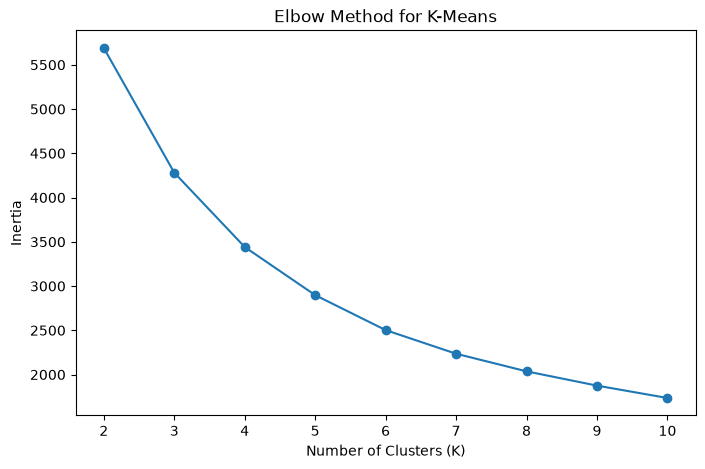

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_results["K"],
    k_results["Inertia"],
    marker="o"
)

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_results["K"])

plt.show()

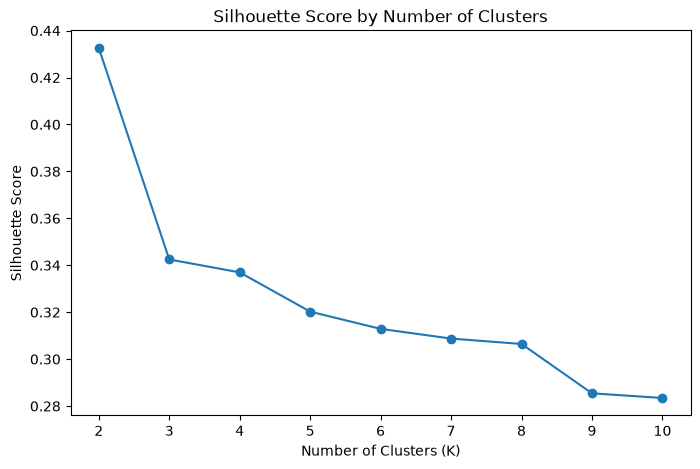

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_results["K"],
    k_results["Silhouette_Score"],
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_results["K"])

plt.show()

In [15]:
for k in [2, 3, 4]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(rfm_scaled)

    comparison = rfm_model[
        ["Recency", "Frequency", "Monetary"]
    ].copy()

    comparison["Cluster"] = labels

    profile = (
        comparison
        .groupby("Cluster")
        .agg(
            Customers=("Cluster", "size"),
            Recency_Median=("Recency", "median"),
            Frequency_Median=("Frequency", "median"),
            Monetary_Median=("Monetary", "median")
        )
    )

    profile["Percentage"] = (
        profile["Customers"] / len(comparison) * 100
    )

    print(f"\nK = {k}")
    display(profile.round(2))


K = 2


,Customers,Recency_Median,Frequency_Median,Monetary_Median,Percentage
Cluster,,,,,
0,1502,16.0,5.0,1836.02,39.4
1,2310,89.0,1.0,333.86,60.6



K = 3


,Customers,Recency_Median,Frequency_Median,Monetary_Median,Percentage
Cluster,,,,,
0,613,8.0,10.0,3482.48,16.08
1,1730,134.0,1.0,283.59,45.38
2,1469,29.0,3.0,979.12,38.54



K = 4


,Customers,Recency_Median,Frequency_Median,Monetary_Median,Percentage
Cluster,,,,,
0,1407,166.0,1.0,288.42,36.91
1,1070,46.0,4.0,1280.71,28.07
2,719,18.0,2.0,380.60,18.86
3,616,7.0,9.0,3350.27,16.16


In [16]:
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

rfm_model["Cluster"] = final_kmeans.fit_predict(rfm_scaled)

print("Customers per cluster:")
display(
    rfm_model["Cluster"]
    .value_counts()
    .sort_index()
)

Customers per cluster:


Cluster
0    1407
1    1070
2     719
3     616
Name: count, dtype: int64

In [17]:
segment_names = {
    0: "Dormant / Low-Value",
    1: "Regular Customers",
    2: "Recent / Developing",
    3: "High-Value Customers"
}

rfm_model["Segment"] = rfm_model["Cluster"].map(segment_names)

display(
    rfm_model[
        ["CustomerID", "Recency", "Frequency", "Monetary", "Cluster", "Segment"]
    ].head(10)
)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,1,Regular Customers
1,12747,2,9,3489.74,3,High-Value Customers
2,12748,1,175,28868.19,3,High-Value Customers
3,12749,4,5,4090.88,3,High-Value Customers
4,12820,3,4,942.34,2,Recent / Developing
5,12821,214,1,92.72,0,Dormant / Low-Value
6,12822,71,2,948.88,1,Regular Customers
7,12823,75,5,1759.50,1,Regular Customers
8,12824,60,1,397.12,0,Dormant / Low-Value
9,12826,3,6,1319.72,3,High-Value Customers


In [18]:
segment_summary = (
    rfm_model
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Recency_Median=("Recency", "median"),
        Frequency_Median=("Frequency", "median"),
        Monetary_Median=("Monetary", "median")
    )
)

segment_summary["Percentage"] = (
    segment_summary["Customers"] / len(rfm_model) * 100
)

segment_summary = segment_summary[
    [
        "Customers",
        "Percentage",
        "Recency_Median",
        "Frequency_Median",
        "Monetary_Median"
    ]
]

display(segment_summary.round(2))

,Customers,Percentage,Recency_Median,Frequency_Median,Monetary_Median
Segment,,,,,
Dormant / Low-Value,1407,36.91,166.0,1.0,288.42
High-Value Customers,616,16.16,7.0,9.0,3350.27
Recent / Developing,719,18.86,18.0,2.0,380.60
Regular Customers,1070,28.07,46.0,4.0,1280.71


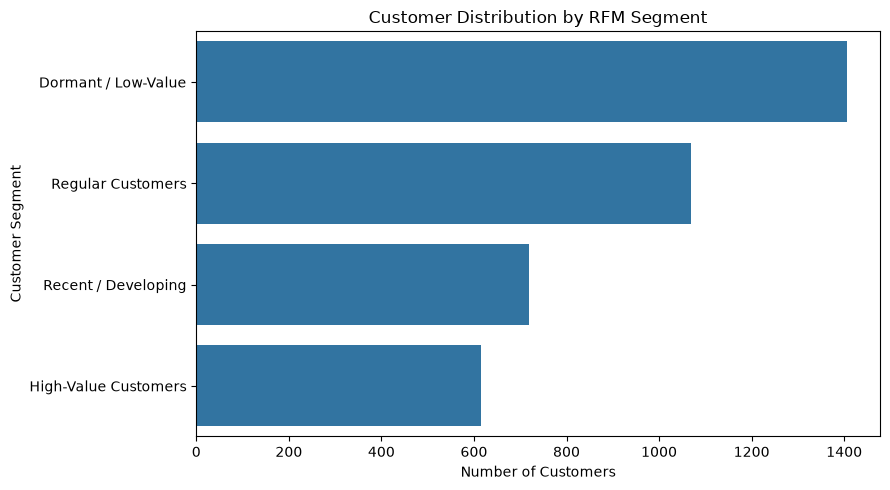

In [19]:
segment_counts = (
    rfm_model["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "Customers"]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_counts,
    x="Customers",
    y="Segment"
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

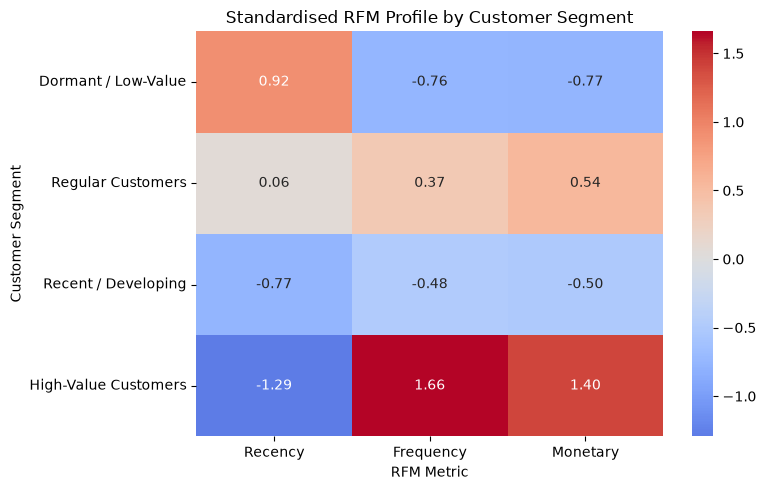

In [20]:
cluster_profile_scaled = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=["Recency", "Frequency", "Monetary"]
)

cluster_profile_scaled["Segment"] = (
    cluster_profile_scaled.index.map(segment_names)
)

cluster_profile_scaled = (
    cluster_profile_scaled
    .set_index("Segment")
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Standardised RFM Profile by Customer Segment")
plt.xlabel("RFM Metric")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

In [21]:
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

rfm_model.to_csv(
    PROCESSED_DATA / "customer_segments.csv",
    index=False
)

segment_summary.to_csv(
    PROCESSED_DATA / "customer_segment_summary.csv"
)

print("Customer segmentation datasets saved successfully.")

Customer segmentation datasets saved successfully.


In [22]:
for file in [
    PROCESSED_DATA / "customer_segments.csv",
    PROCESSED_DATA / "customer_segment_summary.csv"
]:
    print(
        file.name,
        "-",
        round(file.stat().st_size / 1_000_000, 3),
        "MB"
    )

customer_segments.csv - 0.161 MB
customer_segment_summary.csv - 0.0 MB


<b> Customer Segmentation Findings </b>

- RFM analysis was performed using Recency, Frequency and Monetary value for customers with completed purchases.
- One customer with zero monetary value was excluded from clustering because the only recorded transaction had a UnitPrice of 0.
- The RFM variables were highly skewed, especially Frequency and Monetary. A log transformation was applied to reduce skewness before clustering.
- The transformed RFM variables were standardised using StandardScaler so that all three metrics contributed comparably to the K-Means distance calculations.
- K values from 2 to 10 were evaluated using both the Elbow Method and Silhouette Score.
- K = 2 achieved the highest Silhouette Score (0.4326), but K = 4 was selected because it produced more actionable and commercially meaningful customer segments.
- The final four customer segments were:

  - Dormant / Low-Value: 36.91% of customers, with high recency, low frequency and low monetary value.
  - Regular Customers: 28.07%, with moderate recency and above-average frequency and monetary value.
  - Recent / Developing: 18.86%, with recent purchases but relatively low frequency and spending.
  - High-Value Customers: 16.16%, with very recent purchases, high frequency and high monetary value.

- The segmentation provides a practical basis for differentiated marketing strategies such as reactivation, development, retention and VIP targeting.